# This notebook regroups the code around graph formation/estimation -AKM estimator with NRS at ONE and MANY DIMENSIONS)

## Packages and Import

In [4]:
#!pip install seaborn
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn
#!pip install umap-learn
#!pip install pillow

In [5]:
# bibliothéques fondamentales
import matplotlib.pyplot as plt
import pandas as pd
#import bipartitepandas as bpd
import numpy as np
import time
import random
pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning

# Pour faire du ML/DL
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import LabelEncoder
simplefilter("ignore", category=ConvergenceWarning) # Useful for logistic regression

from tensorflow.keras.layers import Input, Dot, Embedding, Add, Flatten, Activation, Layer # Optimisation via tensorflow.keras
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback

pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning
import tensorflow as tf
from keras import regularizers
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Confusion Matrix

# Pour visualisation/ réduction de dimension
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import seaborn as sns
# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn import metrics

# Pour stocker un tuple
import pickle

# Pour calcul de similarité entre les matrices
from numpy.linalg import norm
from sklearn.metrics.pairwise import cosine_similarity

# Afficher un cercle autour d'un point
import matplotlib.patches as patches

# Pour rafraichir les scripts des modules sans redémarrer le kernel
import importlib

# Pour compter le temps d'exécution d'une fonction
import time

#theme
sns.set_theme(style="whitegrid")

In [7]:
# module maison
import script.decorateur as decorateur
import script.graph_formation as graph_formation
import script.MF_NRS as MF_NRS
import script.simulation as simulation
import script.animation as animation
import script.plot_functions as plot_functions
import script.metrique as metrique

# importe la classe directement
GraphFormation = graph_formation.GraphFormation
get_estimations = MF_NRS.get_estimations

# Recharge les modules (A executer en cas de modification des scripts, cela permet d'éviter de restart le kernel)
importlib.reload(decorateur)
importlib.reload(graph_formation)
importlib.reload(MF_NRS)
importlib.reload(simulation)
importlib.reload(metrique)
importlib.reload(animation)
importlib.reload(plot_functions)

<module 'script.plot_functions' from '/home/onyxia/work/G4H_AKM_RS_NRS/script/plot_functions.py'>

## Etude avec EF à une dimension

### Formation du graphe et "training"

In [8]:
graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 13.38%


In [9]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=20, show_print=0, algorithm = "NRS", dim_embedding = 1)

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

# Recuperation de l'objet "model"
model = estimates[4]

### Etudes Préliminaires

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Mean Squared Error sur l'échantillon de test : 0.38556705071658
Precision: 0.67
Recall: 0.51
F1-score: 0.58


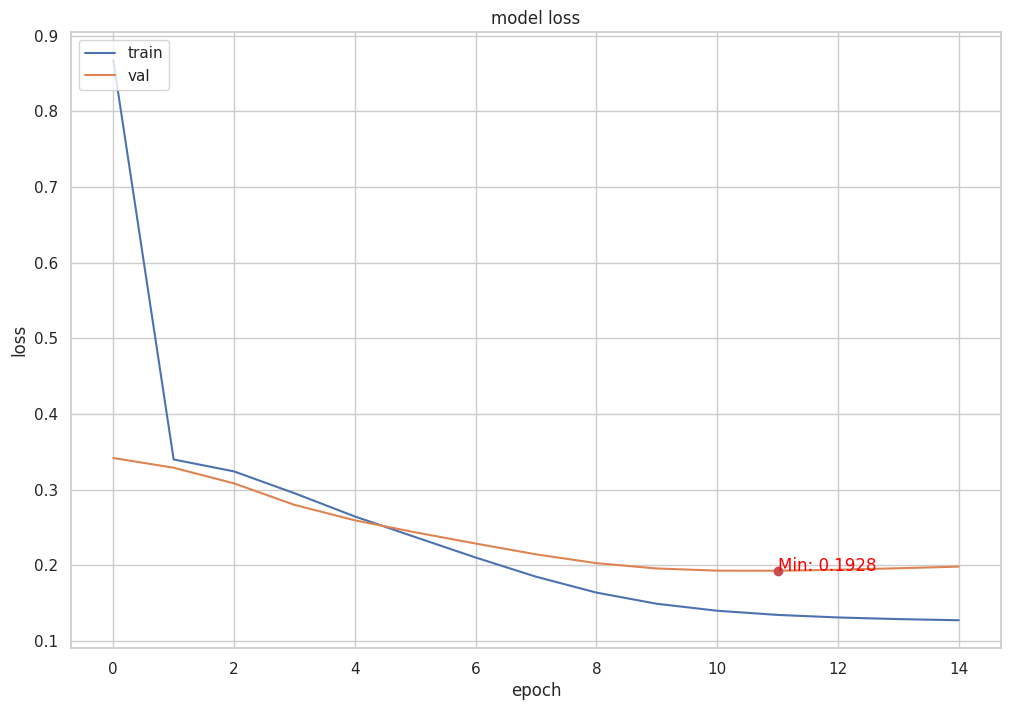

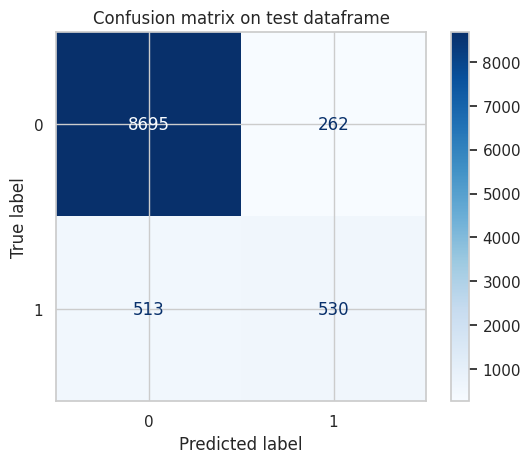

Temps d'exécution : 14 secondes


11

In [321]:
# Temps d'exécution : 15 secondes
MF_NRS.prediction_score(graph_object, nb_epochs=15, algorithm = "NRS", dim_embedding = 1)

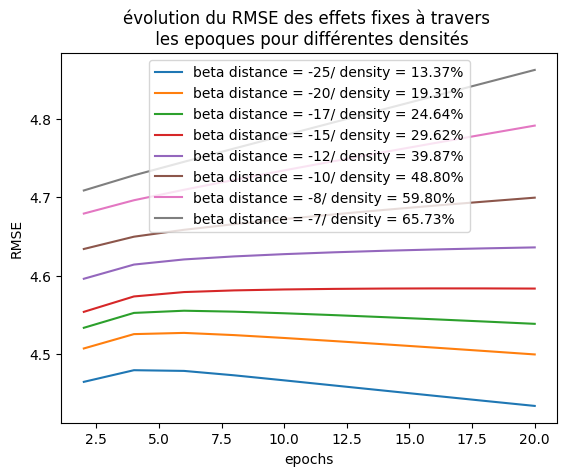

Temps d'exécution : 292 secondes


In [13]:
# Temps d'exécution : 492 secondes
density_ami_rmse_simulation.plot_rmse_epochs(n=10, epochs_step = 2, save=False, algorithm = "NRS")

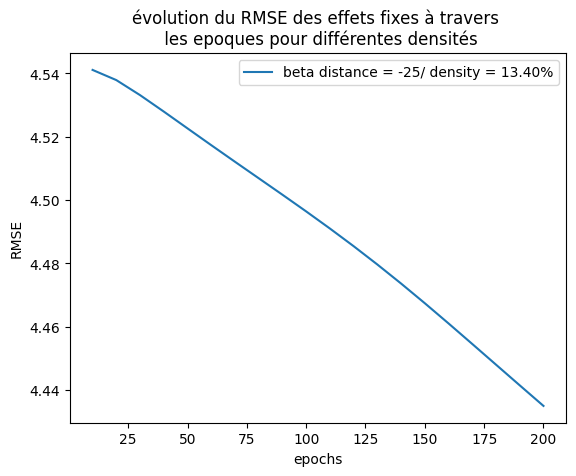

Temps d'exécution : 235 secondes


In [48]:
# Temps d'exécution :  235 secondes
density_ami_rmse_simulation.plot_rmse_epochs(n = 20, sim_beta_distance_array = [-25], save=True, algorithm = "NRS")

### Etudes du Clustering

#### Visualisation

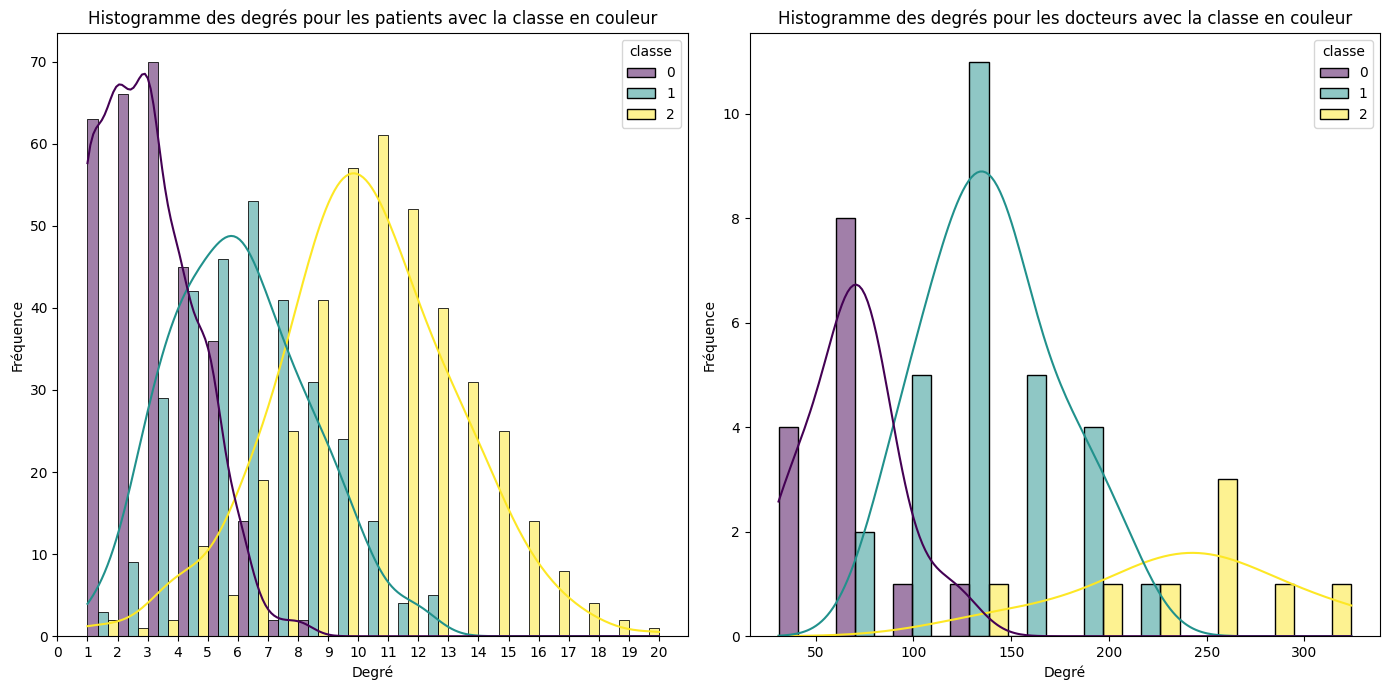

In [37]:
plot_functions.plot_hist_degree(graph_object, hue_class = True, save = False)

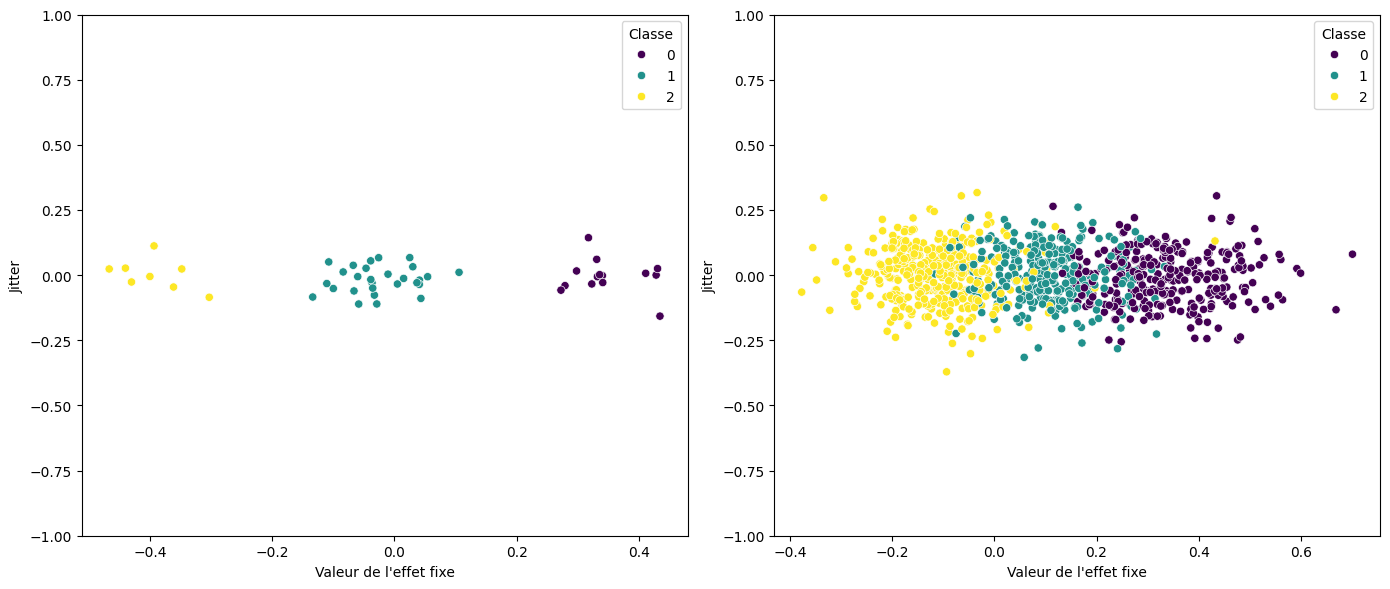

In [36]:
plot_functions.plot_ef_1D(graph_object, ef_patient = ef_patient_hat, ef_doctor = ef_doctor_hat)

#### Clustering et métriques

Inertia: Sum of squared distances of samples to their closest cluster center, weighted by the sample weights if provided.

In [10]:
tab_kmeans = metrique.tab_ami_kmeans_inertia(graph_object, ef_patient= ef_patient_hat, ef_doctor = ef_doctor_hat, save = False,return_ = True)

    K  Inertia patient  AMI patient  Inertia doctor  AMI doctor
0   2         9.265455     0.479252        1.365134    0.372738
1   3         4.682715     0.701436        0.179795    1.000000
2   4         2.875712     0.434633        0.120194    0.663340
3   5         1.988019     0.413411        0.066461    0.567937
4   6         1.373550     0.408985        0.048238    0.536082
5   7         1.066131     0.331619        0.036912    0.409229
6   8         0.804922     0.308812        0.029311    0.341547
7   9         0.675407     0.285511        0.027894    0.332978
8  10         0.604869     0.267866        0.018723    0.302789


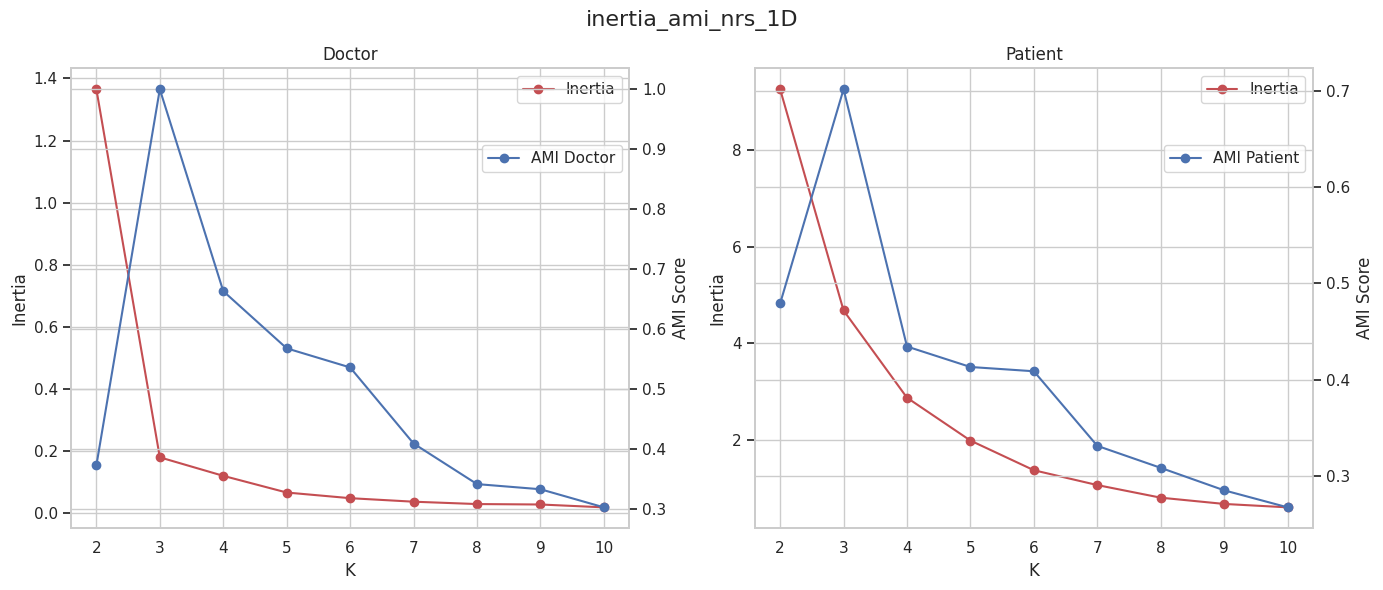

In [11]:
plot_functions.plot_tab_ami_inertia_kmeans(tab_kmeans, save = True, title="inertia_ami_nrs_1D")

#### AMI et coefficient de régularisation

Simulation 1: done !
Simulation 2: done !
Simulation 3: done !
Simulation 4: done !
Simulation 5: done !
Simulation 6: done !
Simulation 7: done !


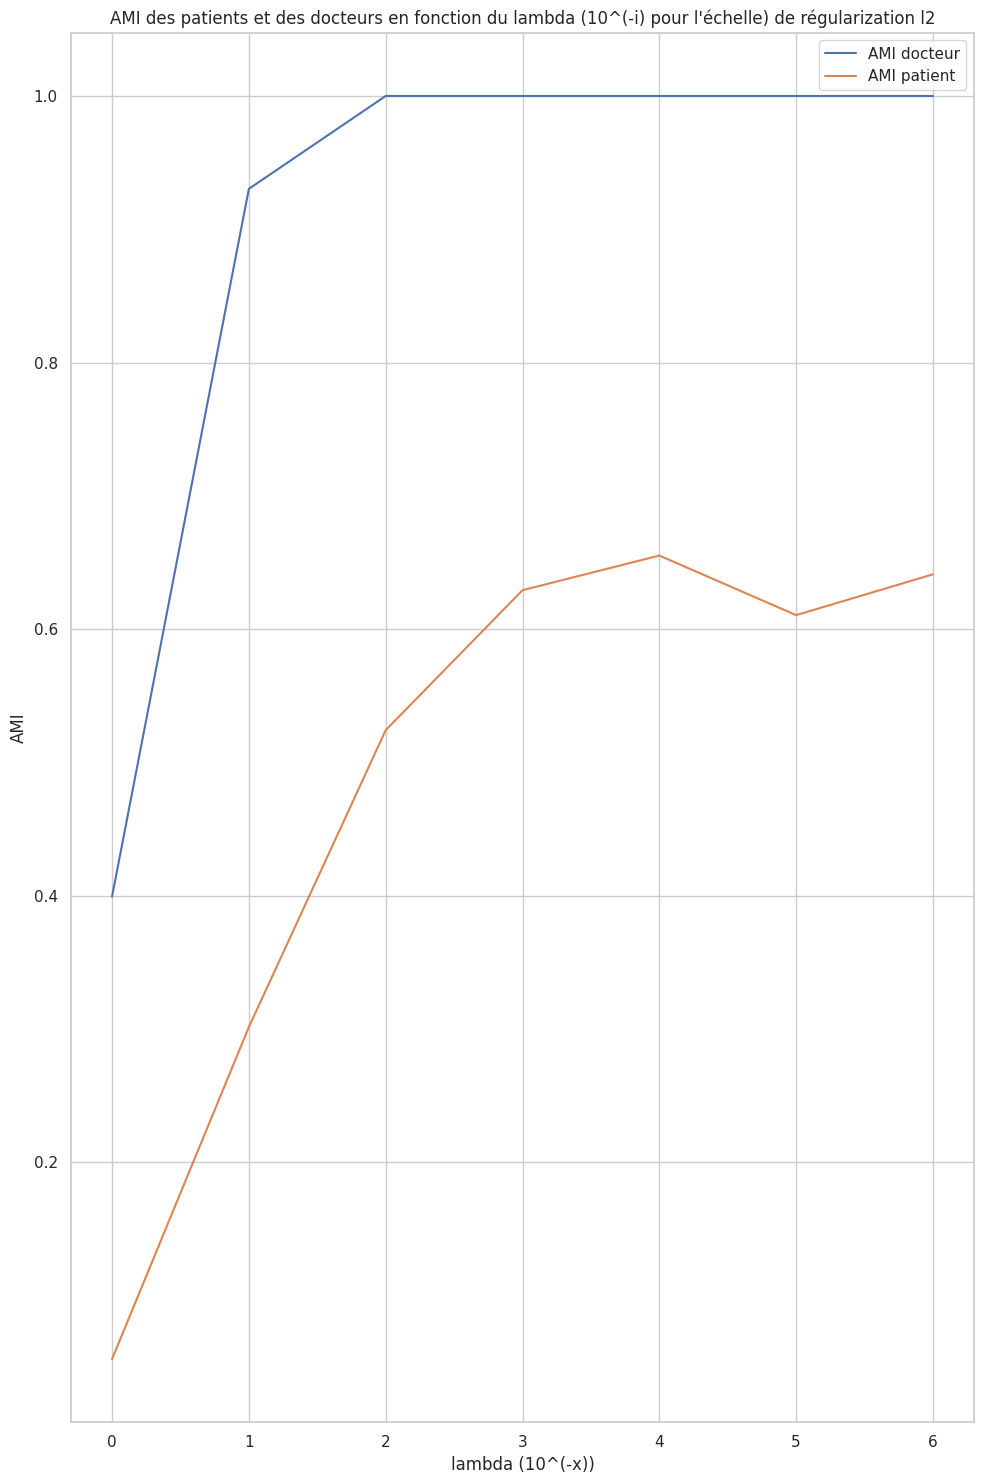

In [221]:
simulation.simulation_ami_lambda( regu_lambdas = np.array([10**(-i) for i in range(7)]), nb_epochs=30, save=True, algorithm = "NRS" )

### Robustesse

In [ ]:
simulation.robustesse_all(100, 0.8, graph_object, nb_epochs = 30, dim_embedding = 1,  algorithm = "NRS")

simulation 1: done
simulation 2: done
simulation 3: done
simulation 4: done
simulation 5: done
simulation 6: done
simulation 7: done
simulation 8: done
simulation 9: done
simulation 10: done
simulation 11: done


## Etude avec EF en dimension 2

### Formation du graphe et "training"

In [12]:
#Exemple de foramtion de graphe avec des EF 2D
alpha_law_means = [[0,1], [1,-1], [2,0]]
psi_law_means = [[1,1], [1,-1], [-1,2]]
identity_matrices = np.array([np.eye(2) for _ in range(3)])


graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -20,
                    dilatation_p = 1.5,
                    dilatation_d = 1.5,
                    alpha_law_means = alpha_law_means,
                    psi_law_means = psi_law_means,
                    psi_law_stds= identity_matrices,
                    alpha_law_stds = identity_matrices,
                    std_multiplier_p=0,
                    std_multiplier_d=0,
                    nb_latent_factors=2)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 11.29%


In [13]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=30, show_print=0, algorithm = "NRS", dim_embedding = 2)

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

### Etude Préliminaires

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Mean Squared Error sur l'échantillon de test : 0.3095773316333591
Precision: 0.73
Recall: 0.71
F1-score: 0.72


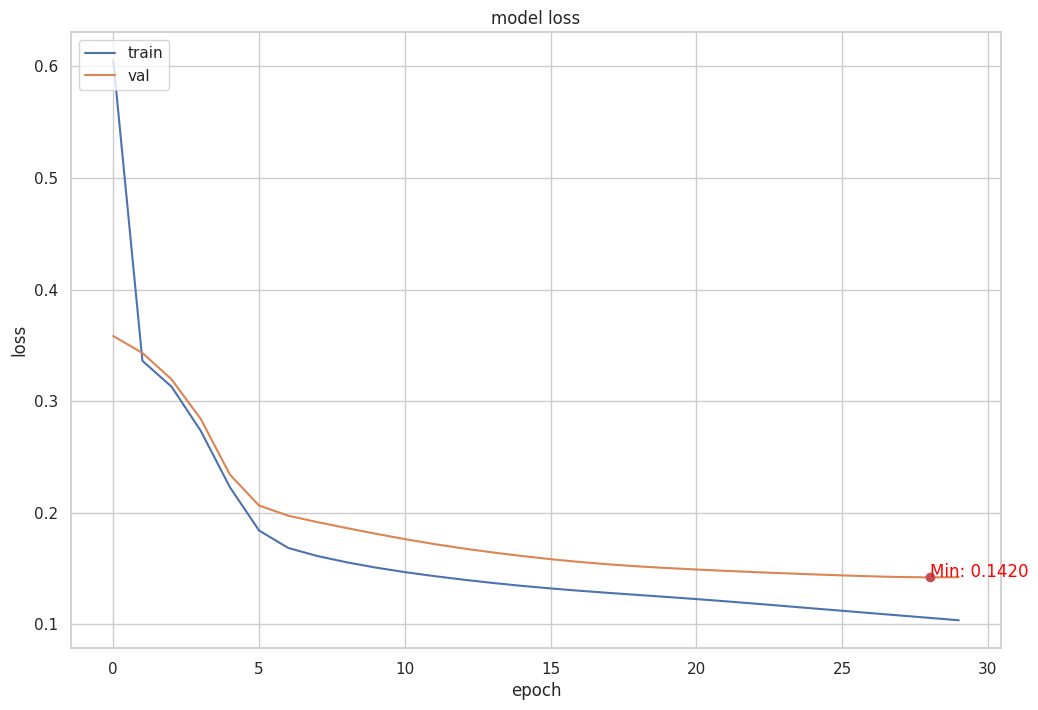

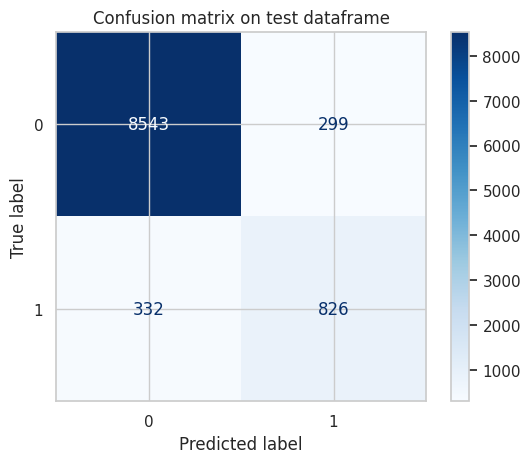

Temps d'exécution : 25 secondes


In [71]:
#Temps d'exécution : 285 secondes
MF_NRS.prediction_score(graph_object, dim_embedding=2, nb_epochs=30, algorithm = "NRS")

### Etudes Clustering

#### Visualisation

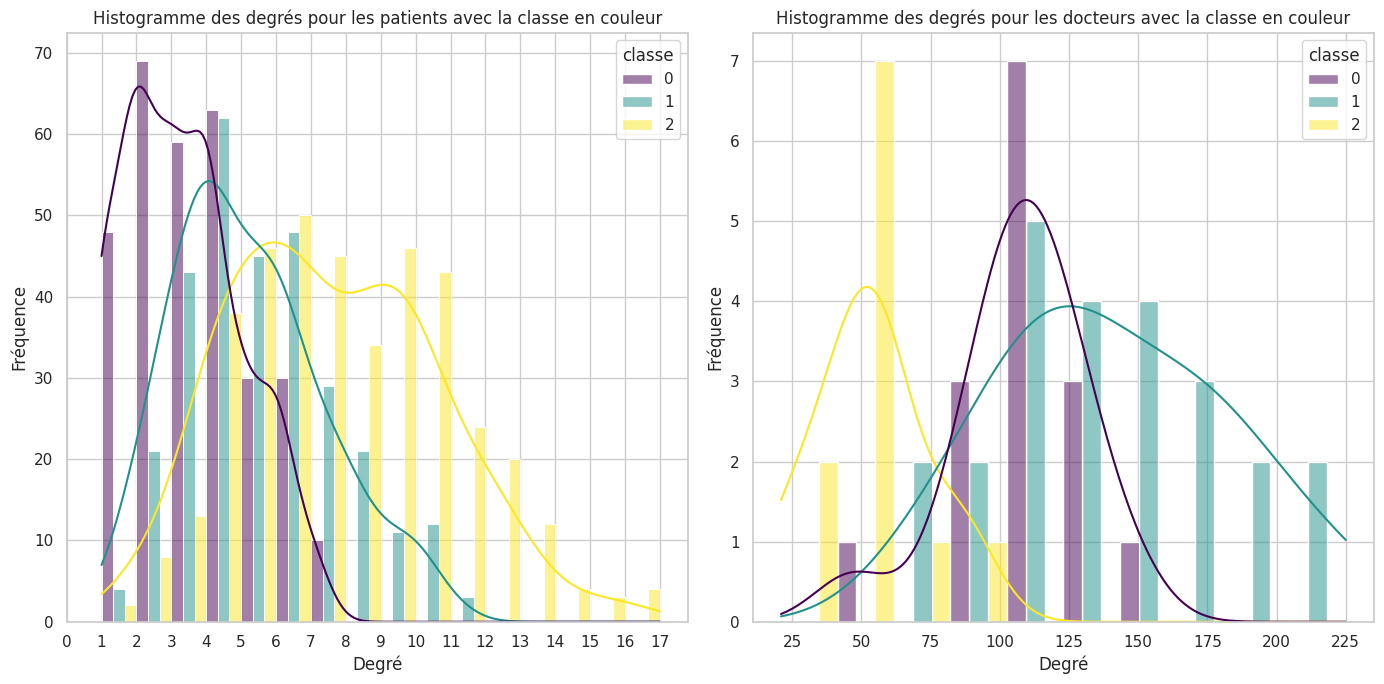

In [103]:
plot_functions.plot_hist_degree(graph_object, hue_class = True, save = False)

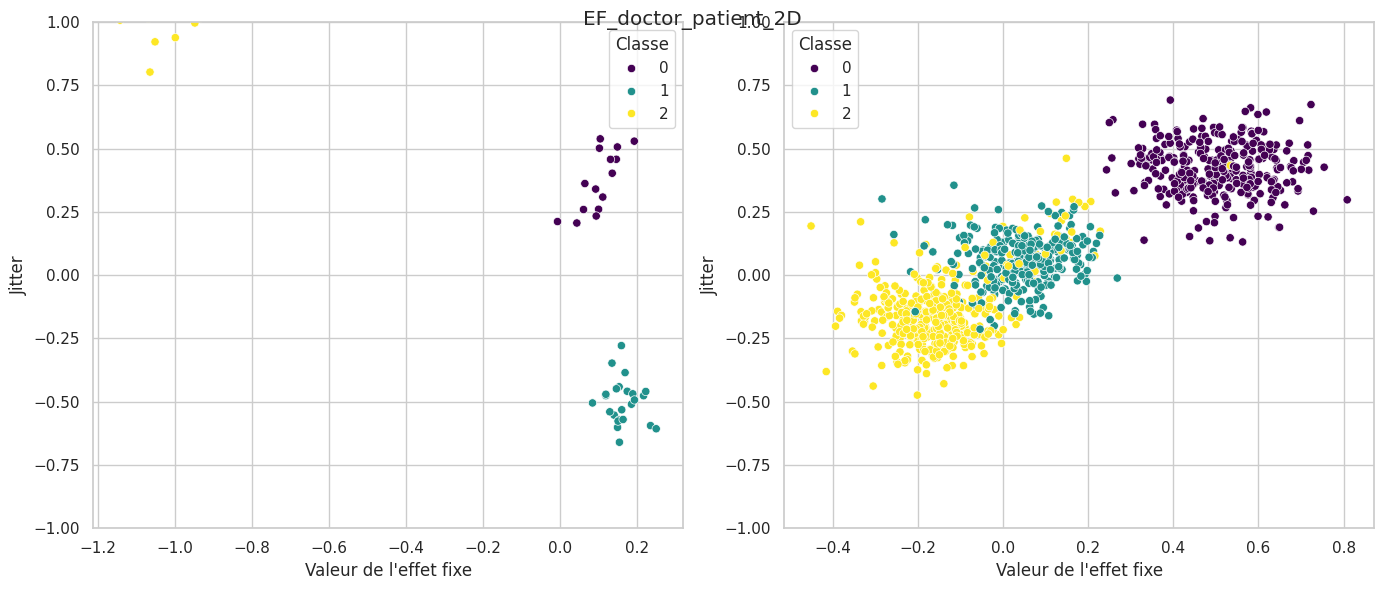

In [74]:
plot_functions.plot_ef_2D(graph_object, ef_patient = ef_patient_hat, ef_doctor = ef_doctor_hat)

#### Clustering et métriques

In [14]:
tab_kmeans = metrique.tab_ami_kmeans_inertia(graph_object, ef_patient= ef_patient_hat, ef_doctor = ef_doctor_hat, save = False,return_ = True)

    K  Inertia patient  AMI patient  Inertia doctor  AMI doctor
0   2        29.875853     0.532814        7.592361    0.458954
1   3        12.500776     0.780067        0.634087    1.000000
2   4        10.081177     0.670944        0.472644    0.897342
3   5         7.617544     0.550431        0.370012    0.622977
4   6         6.929353     0.513741        0.278179    0.605389
5   7         5.607368     0.412607        0.192729    0.537980
6   8         5.175611     0.366466        0.156358    0.531110
7   9         4.577000     0.352423        0.138710    0.501058
8  10         3.951432     0.311678        0.114214    0.487033


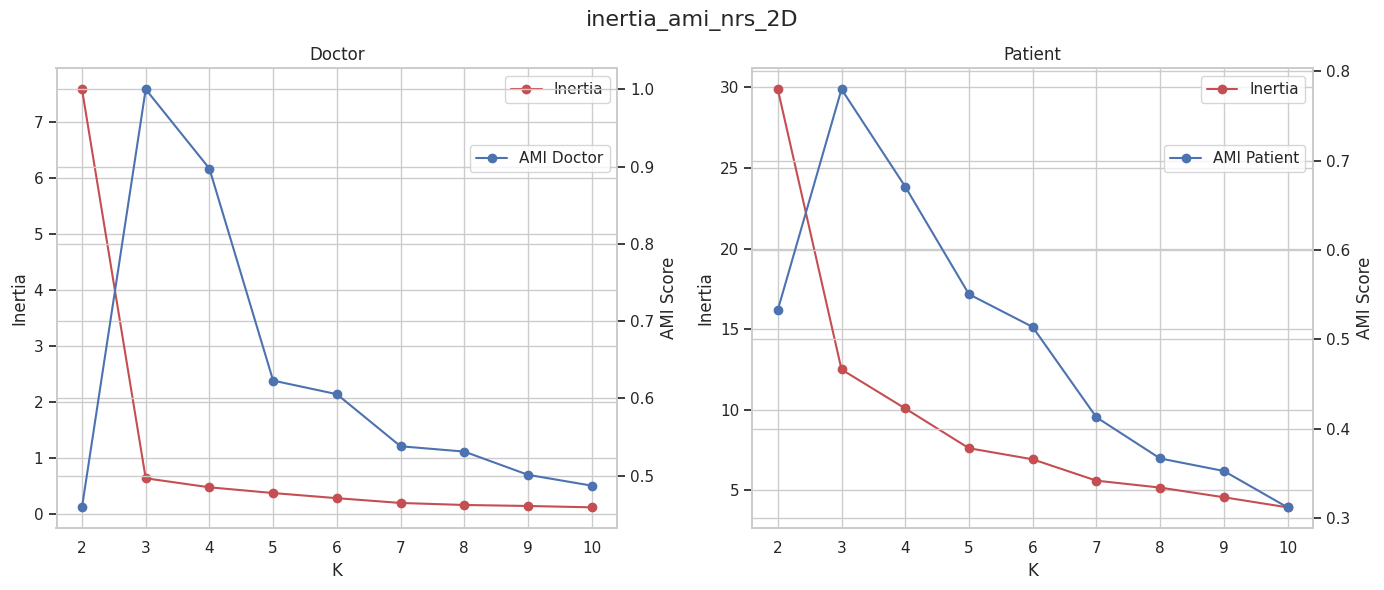

In [15]:
plot_functions.plot_tab_ami_inertia_kmeans(tab_kmeans, save = True, title="inertia_ami_nrs_2D")

### Robustesse

In [ ]:
simulation.robustesse_all(100, 0.8, graph_object, nb_epochs = 30, dim_embedding = 2,  algorithm = "NRS")

simulation 1: done


## Etude avec EF en dimension 5 (sphère)

### Formation du graphe et "training"

In [16]:
#Exemple de foramtion de graphe avec des EF 5D (gaussian sphere)
identity_matrices = np.array([np.eye(5) for _ in range(6)])


graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25,
                    psi_law_stds= identity_matrices,
                    alpha_law_stds = identity_matrices,
                    std_multiplier_p=0.3,
                    std_multiplier_d=0.5,
                    nb_latent_factors=5,
                    gaussian_sphere = True,
                    radius = 4,
                    seed=12)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 10.79%


In [18]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=20, show_print=0, algorithm = "NRS", dim_embedding = 5)

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

### Etudes Préliminaires

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.3151439120355152
Precision: 0.72
Recall: 0.66
F1-score: 0.69


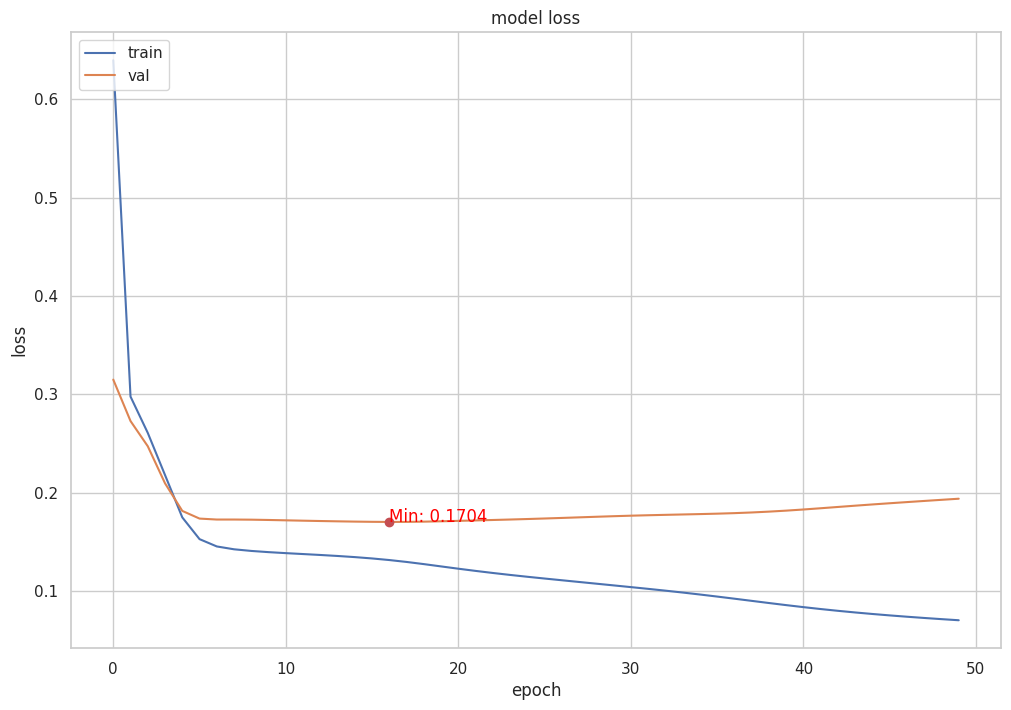

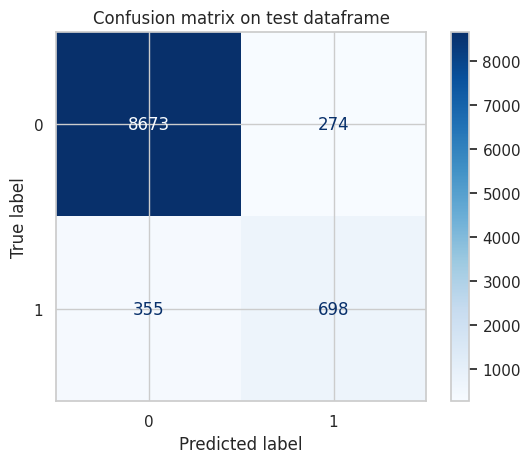

Temps d'exécution : 47 secondes


In [88]:
MF_NRS.prediction_score(graph_object, dim_embedding=5, nb_epochs=50, algorithm = "NRS")

### Etudes Clustering

#### Visualisation

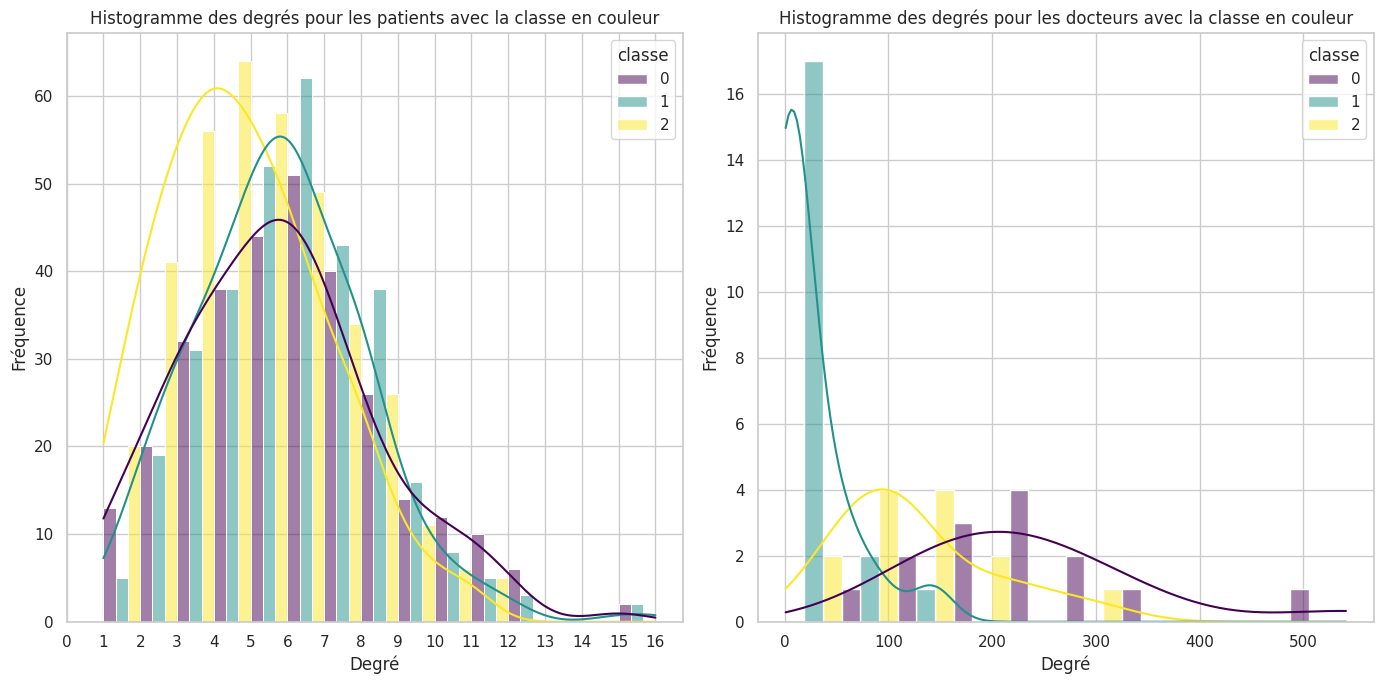

In [313]:
plot_functions.plot_hist_degree(graph_object, hue_class = True, save = False)

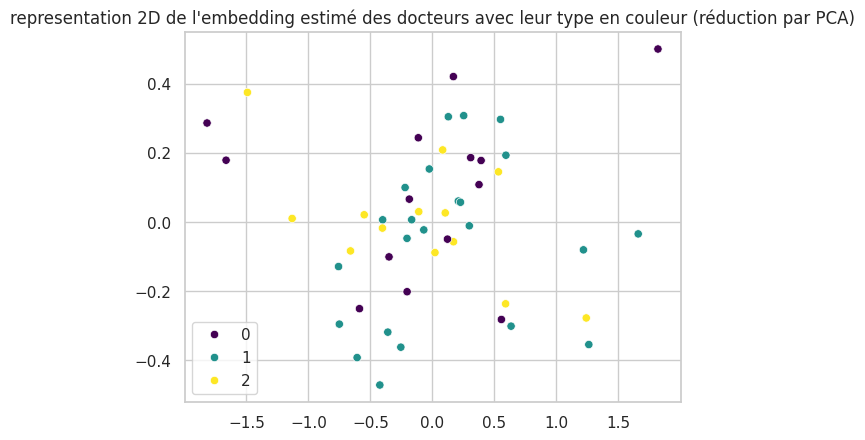

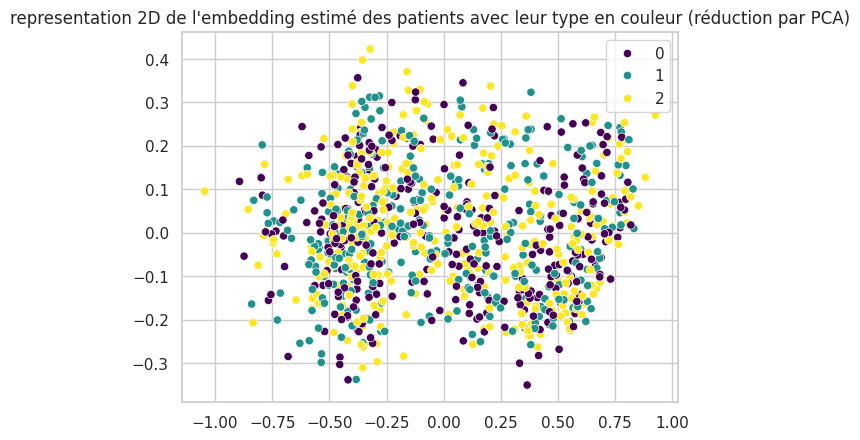

Temps d'exécution : 0 secondes


In [314]:
plot_functions.plot_ef_RD(graph_object, ef_patient_hat, ef_doctor_hat, label_doctor = None, label_patient = None, RD_method = "PCA", save = False)

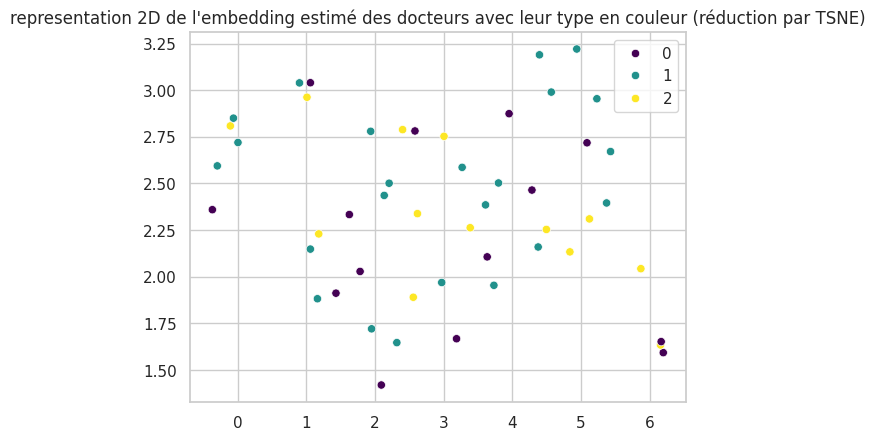

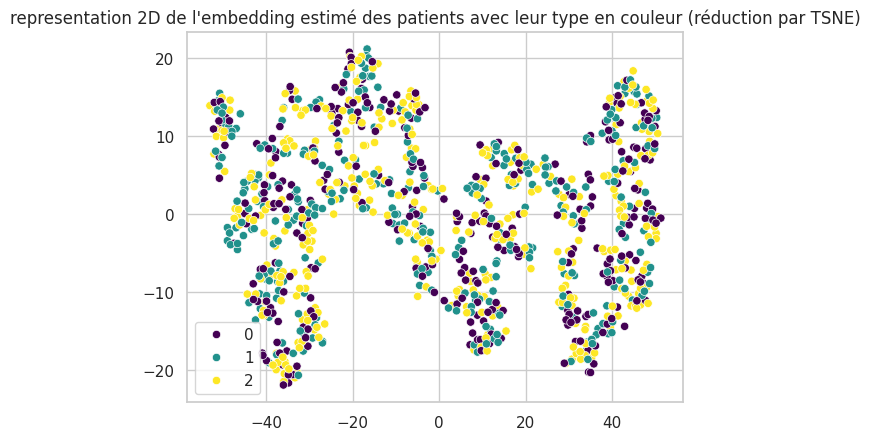

Temps d'exécution : 7 secondes


In [315]:
plot_functions.plot_ef_RD(graph_object, ef_patient_hat, ef_doctor_hat, label_doctor = None, label_patient = None, RD_method = "TSNE", save = False)

In [ ]:
plot_functions.plot_ef_RD(graph_object, ef_patient_hat, ef_doctor_hat, label_doctor = None, label_patient = None, RD_method = "UMAP", save = False)

#### Clustering et métriques

In [19]:
tab_kmeans = metrique.tab_ami_kmeans_inertia(graph_object, ef_patient= ef_patient_hat, ef_doctor = ef_doctor_hat, save = False,return_ = True)

    K  Inertia patient  AMI patient  Inertia doctor  AMI doctor
0   2       108.723465     0.073916       23.133984    0.546928
1   3        84.048111     0.061175       10.461061    0.509359
2   4        63.713360     0.074804        7.061490    0.622563
3   5        54.194977     0.081463        6.188360    0.617423
4   6        44.820026     0.084480        3.864904    0.428163
5   7        40.184578     0.060762        3.410792    0.377828
6   8        36.165710     0.058403        2.986532    0.329737
7   9        32.673264     0.054752        2.616912    0.241239
8  10        30.375092     0.049289        2.421141    0.219870


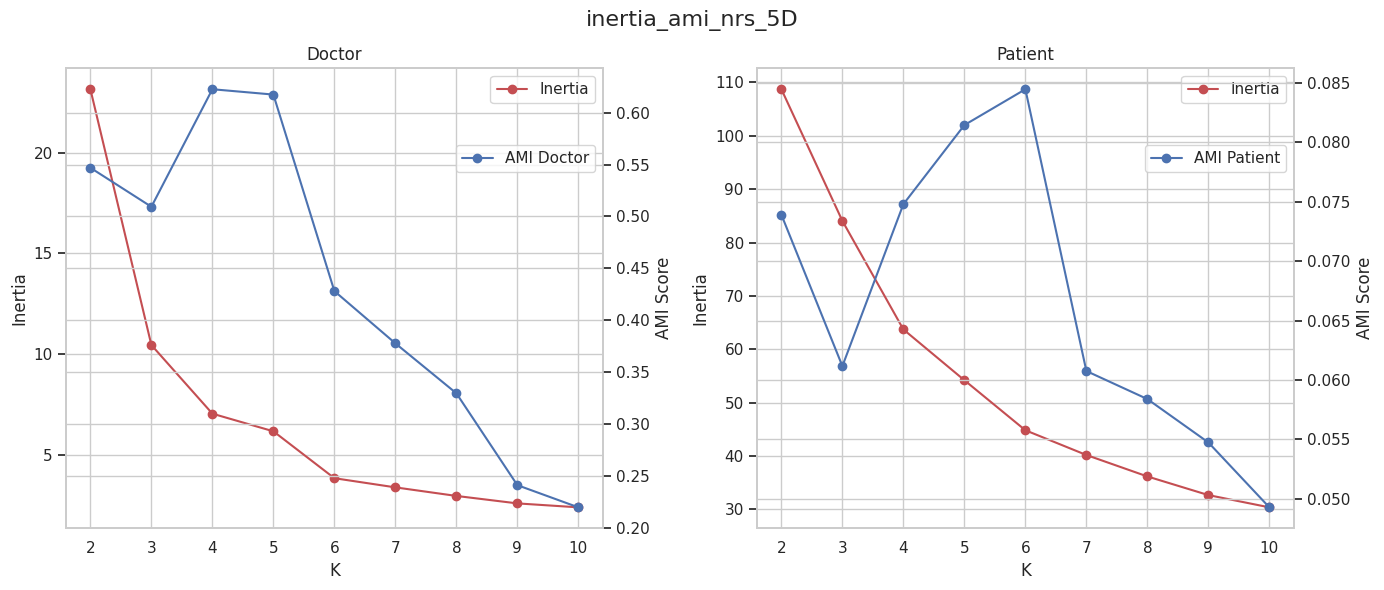

In [20]:
plot_functions.plot_tab_ami_inertia_kmeans(tab_kmeans, save = True, title="inertia_ami_nrs_5D")

### Robustesse

In [316]:
simulation.robustesse_all(100, 0.8, graph_object, nb_epochs = 30, dim_embedding = 5, algorithm = "NRS")

simulation 1: done
simulation 2: done
simulation 3: done
simulation 4: done
simulation 5: done
simulation 6: done
simulation 7: done
simulation 8: done
simulation 9: done
simulation 10: done
simulation 11: done
simulation 12: done
simulation 13: done
simulation 14: done
simulation 15: done
simulation 16: done
simulation 17: done
simulation 18: done
simulation 19: done
simulation 20: done
simulation 21: done
simulation 22: done
simulation 23: done
simulation 24: done
simulation 25: done
simulation 26: done
simulation 27: done
simulation 28: done
simulation 29: done
simulation 30: done
simulation 31: done
simulation 32: done
simulation 33: done
simulation 34: done
simulation 35: done
simulation 36: done
simulation 37: done
simulation 38: done
simulation 39: done
simulation 40: done
simulation 41: done
simulation 42: done
simulation 43: done
simulation 44: done
simulation 45: done
simulation 46: done
simulation 47: done
simulation 48: done
simulation 49: done
simulation 50: done
simulatio